# MLP Scaling: $H$ vs $|G|$ 

Hidden neurons vs group size scaling experiments.

## Set up

In [8]:
%load_ext autoreload
%autoreload 2
%load_ext jupyter_black

import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Ensure the project root is on sys.path so `src.*` imports work
_project_root = subprocess.check_output(
    ["git", "rev-parse", "--show-toplevel"], text=True
).strip()
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.sweep_analysis import (
    discover_sweep_params,
    export_lightweight_data,
    load_lightweight_data,
    load_sweep_results_grid,
    load_training_loss_curves,
    plot_theory_boundaries,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black


## Specify experiment directory

In [9]:
lightweight = True  # True: load from pre-computed .npz (small, for GitHub demo)

sweep_dir = Path(_project_root) / "sweep_results" / "merged_scaling_sweep"
lightweight_path = (
    Path(_project_root) / "notebooks" / "data" / "scaling_sweep_lightweight.npz"
)

if lightweight:
    print(f"Lightweight mode: loading from {lightweight_path.name}")
    _lw = load_lightweight_data(lightweight_path)
else:
    print(f"Full mode: loading from {sweep_dir}")
    _lw = None

Lightweight mode: loading from scaling_sweep_lightweight.npz


## Specify sweep parameter values

In [10]:
if lightweight:
    p_values = _lw["p_values"].tolist()
    hidden_dims = _lw["hidden_dims"].tolist()
    k_values = _lw["k_values"].tolist()
else:
    p_values, hidden_dims, k_values = discover_sweep_params(sweep_dir)

print(f"k_values:    {k_values}")
print(f"p_values:    {p_values}")
print(f"hidden_dims: {hidden_dims}")

k_values:    [2, 3, 4, 5]
p_values:    [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
hidden_dims: [18, 36, 54, 72, 90, 108, 126, 144, 162, 180, 198, 216, 234, 252, 270, 288, 306, 324, 342, 360, 378]


## Final Training Loss Heatmap

/tmp/ipykernel_333233/2248852791.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


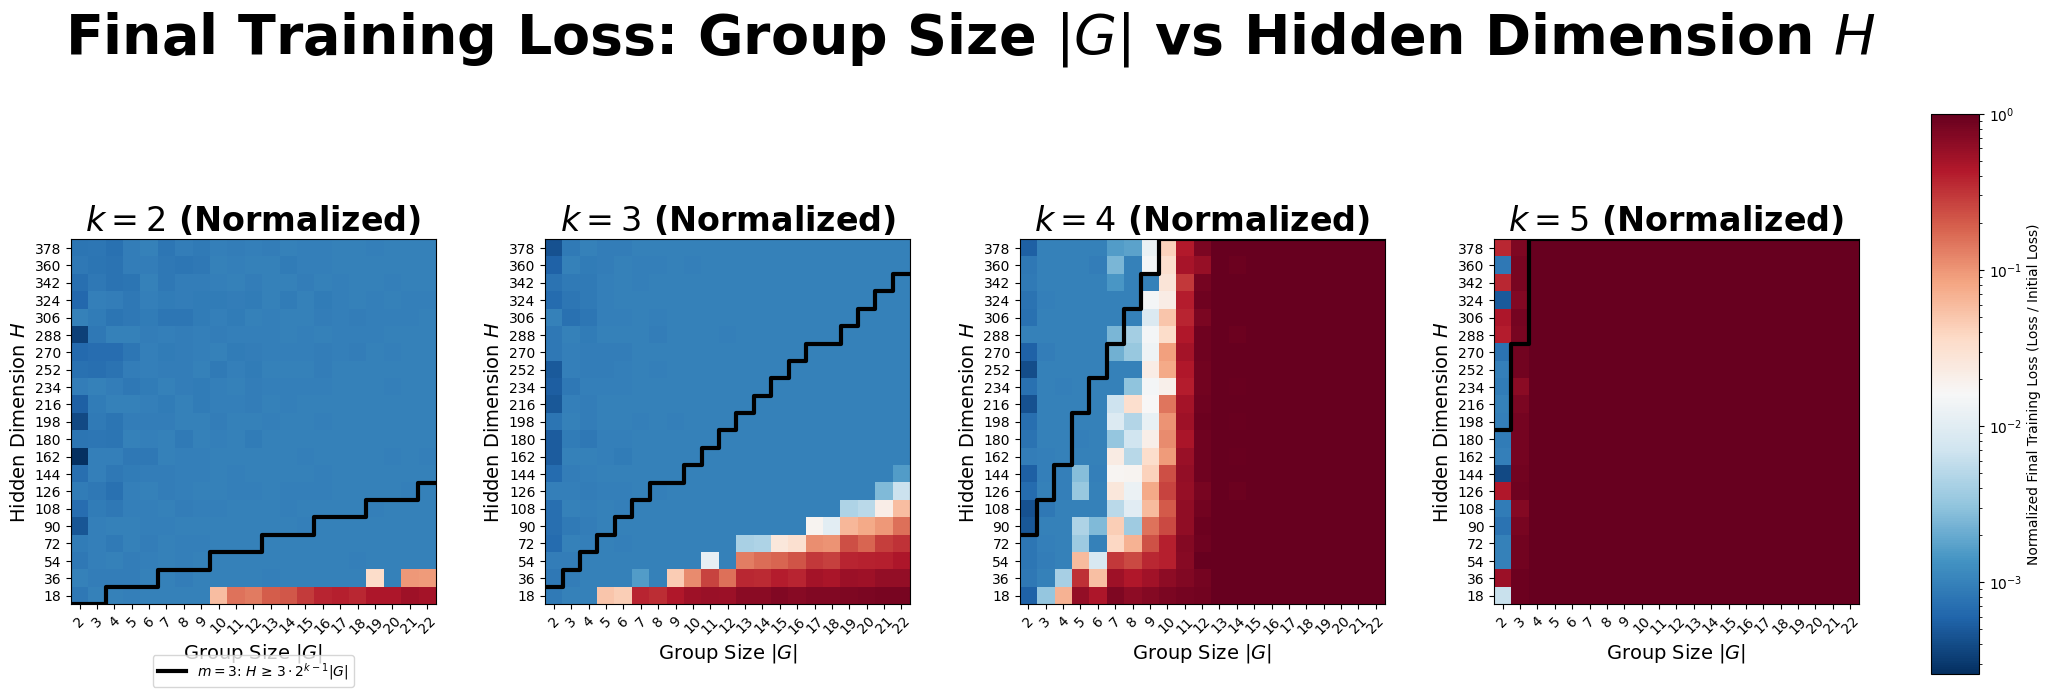

In [11]:
from matplotlib.colors import LogNorm

# Load final training loss data for each k value separately
max_p = 100
normalize_init_loss = True  # Set to True to normalize by initial loss

# Filter p values - only show p <= max_p
p_values_filtered = [p for p in p_values if p <= max_p]
n_p_filt = len(p_values_filtered)

# First, load all data to find global min/max for shared colorbar
all_loss_grids = {}
for k in k_values:
    if lightweight:
        loss_grid = _lw[f"final_loss_k{k}"][:, :n_p_filt].copy()
    else:
        loss_grid, _ = load_sweep_results_grid(
            sweep_dir, k, p_values, hidden_dims, metric="final_loss", max_p=max_p
        )

    if normalize_init_loss:
        if lightweight:
            init_loss_grid = _lw[f"initial_loss_k{k}"][:, :n_p_filt]
        else:
            init_loss_grid, _ = load_sweep_results_grid(
                sweep_dir, k, p_values, hidden_dims, metric="initial_loss", max_p=max_p
            )
        mask = ~(np.isnan(loss_grid) | np.isnan(init_loss_grid))
        loss_grid[mask] = loss_grid[mask] / init_loss_grid[mask]

    all_loss_grids[k] = loss_grid[:, :n_p_filt]

# Find global min/max across all k values (ignoring NaN)
all_valid_values = np.concatenate(
    [grid[~np.isnan(grid)].flatten() for grid in all_loss_grids.values()]
)
vmin, vmax = np.min(all_valid_values), np.max(all_valid_values)
norm = LogNorm(vmin=vmin, vmax=vmax)

# Create subplots: one for each k value, with extra space for colorbar
fig, axes = plt.subplots(
    1,
    len(k_values),
    figsize=(6 * len(k_values), 8),
    gridspec_kw={"wspace": 0.3},
)

if len(k_values) == 1:
    axes = [axes]  # Make it iterable

# cmap = plt.cm.viridis_r.copy()
cmap = plt.cm.RdBu_r.copy()
# cmap.set_bad(color="black")

for idx, k in enumerate(k_values):
    ax = axes[idx]
    loss_grid = all_loss_grids[k]

    im = ax.imshow(
        loss_grid,
        aspect="equal",
        cmap=cmap,
        norm=norm,
    )

    ax.set_xlabel("Group Size $|G|$", fontsize=14)
    ax.set_ylabel("Hidden Dimension $H$", fontsize=14)
    ax.set_xticks(range(len(p_values_filtered)))
    ax.set_xticklabels(p_values_filtered, rotation=45, ha="center")

    # Set y-axis ticks (hidden dimensions)
    ax.set_yticks(range(len(hidden_dims)))
    ax.set_yticklabels(hidden_dims)
    ax.invert_yaxis()

    # Theory boundaries: H = m * 2^{k-1} * |G| for m = 1, 2, ..., k+1
    plot_theory_boundaries(
        ax,
        k,
        p_values_filtered,
        hidden_dims,
        use_ax=True,
        show_minor=False,
    )

    # Place legend outside the plot area (only for the first subplot)
    if idx == 0:
        ax.legend(
            loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=10, frameon=True
        )
    else:
        ax.legend().set_visible(False)

    title_suffix = " (Normalized)" if normalize_init_loss else ""
    ax.set_title(
        f"$k={k}${title_suffix}",
        fontsize=24,
        fontweight="bold",
    )

# Add a single shared colorbar on the right side
colorbar_label = (
    "Normalized Final Training Loss (Loss / Initial Loss)"
    if normalize_init_loss
    else "Final Training Loss"
)

# Adjust layout first, then add colorbar
fig.tight_layout()
fig.subplots_adjust(right=0.87, top=0.82)  # Make room for colorbar on the right

# Add colorbar in dedicated space on the right
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label=colorbar_label)

fig.suptitle(
    "Final Training Loss: Group Size $|G|$ vs Hidden Dimension $H$",
    fontsize=40,
    fontweight="bold",
    y=0.98,
)

plt.show()

## Training Loss Curves (fixed $H$, varying $|G|$)

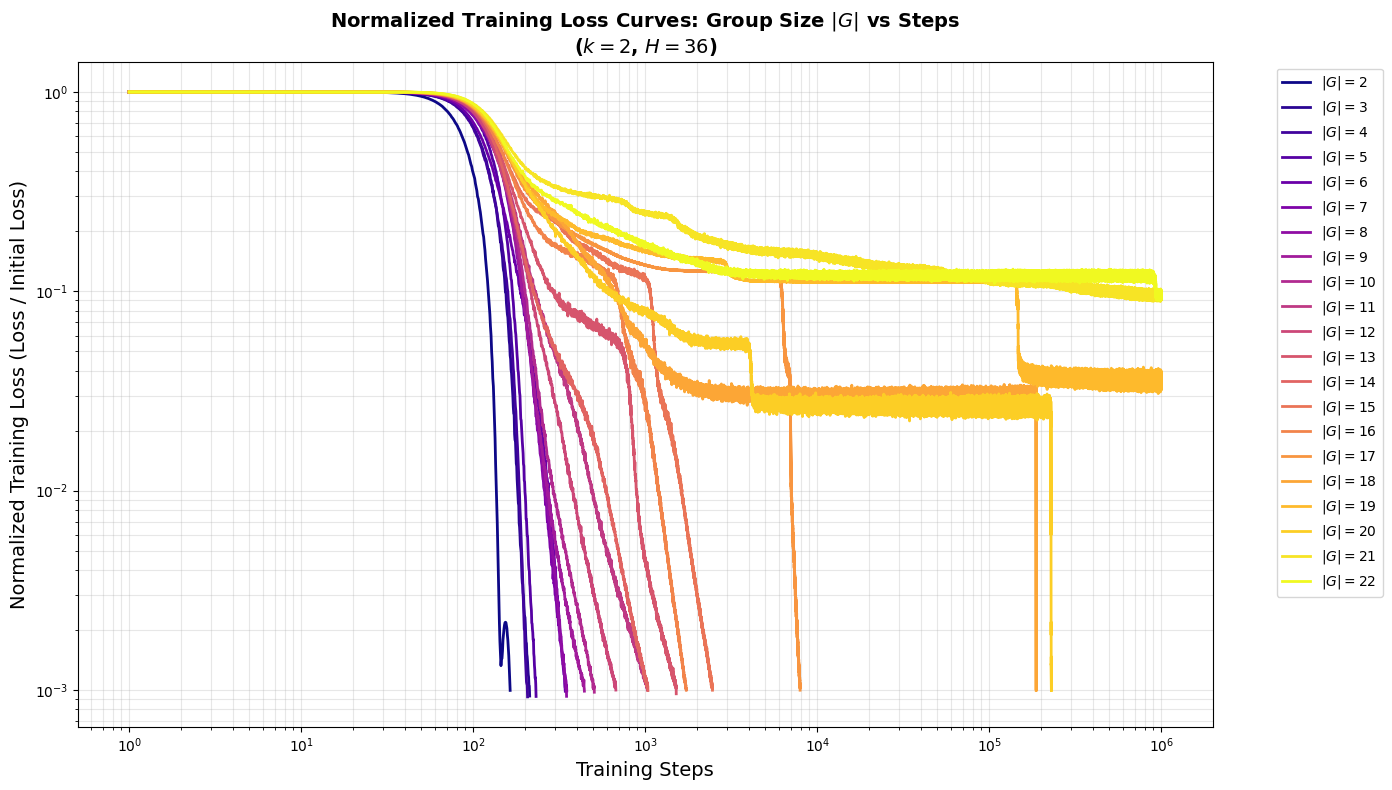

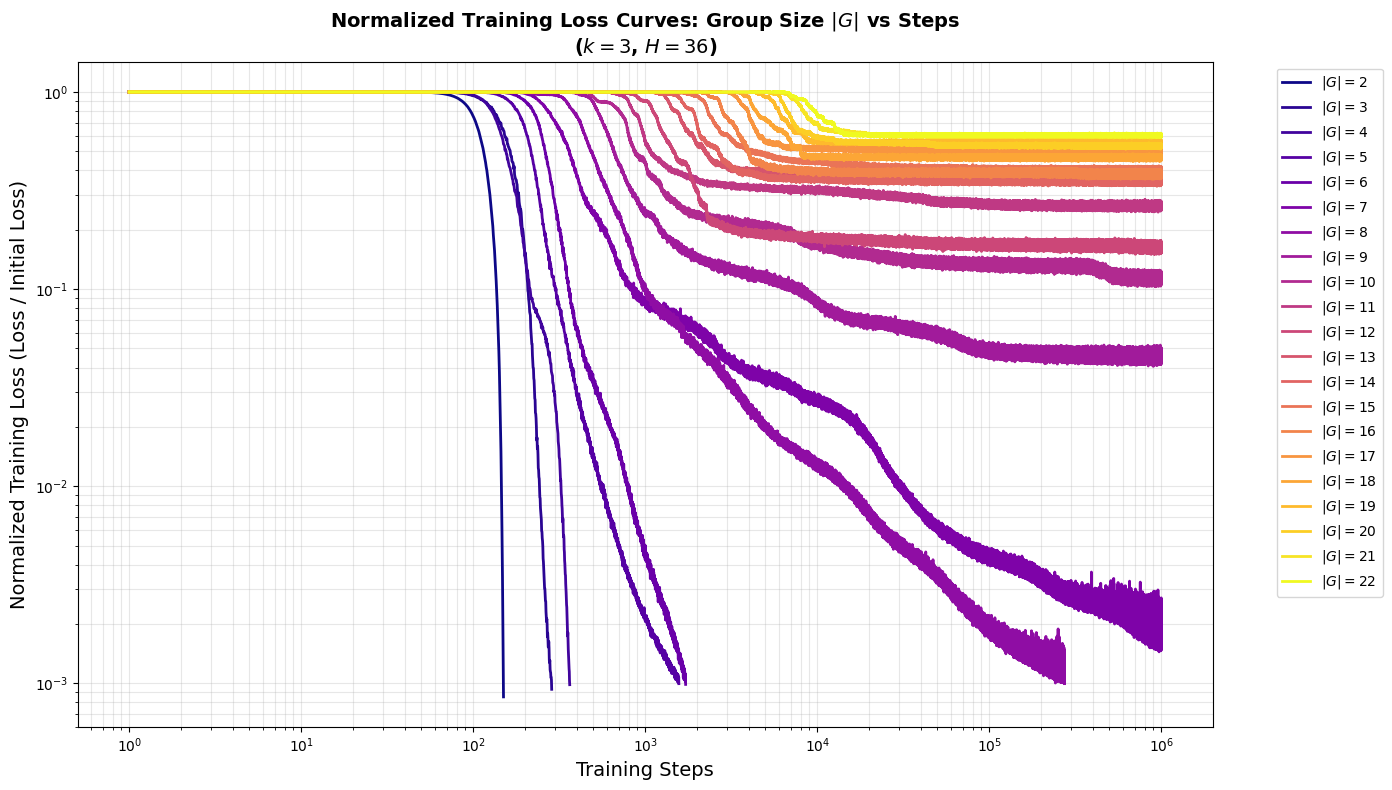

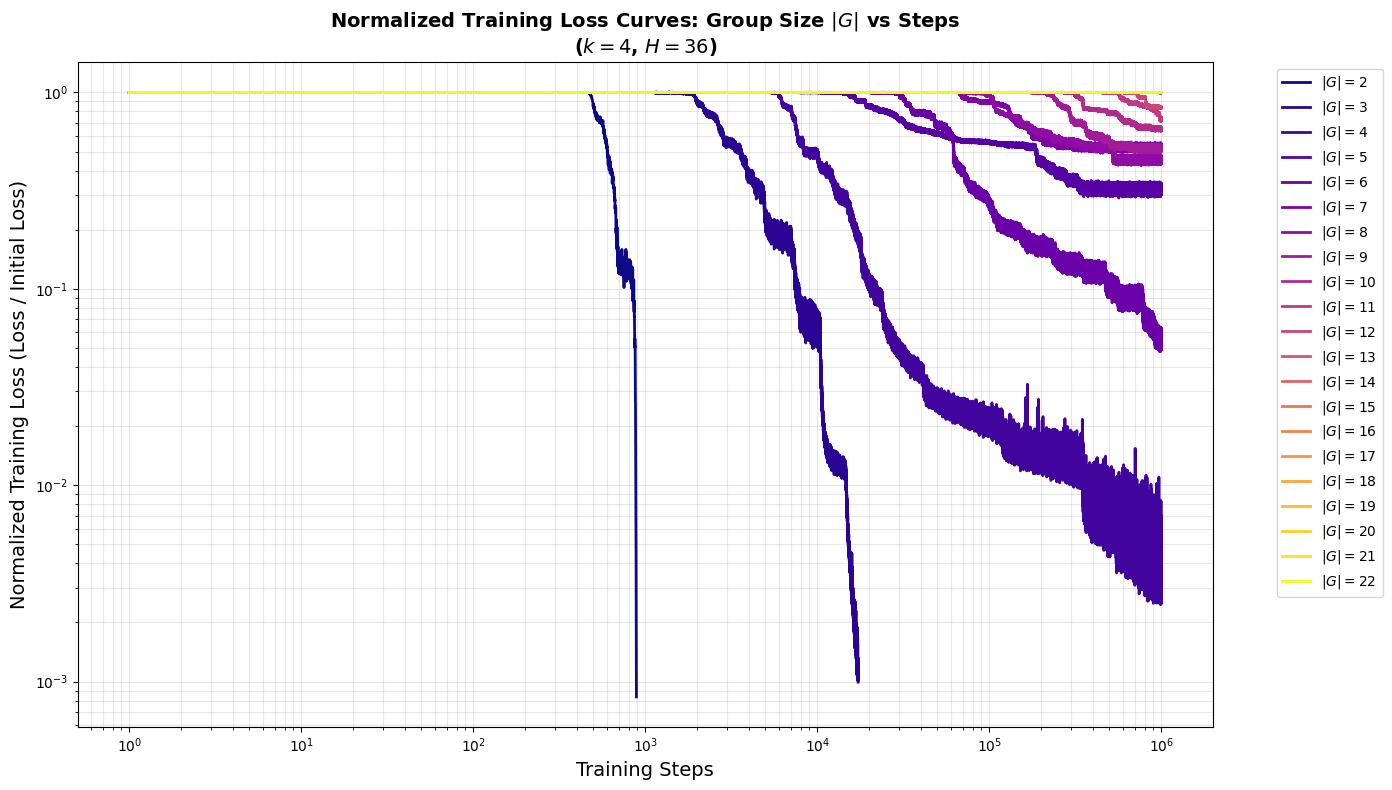

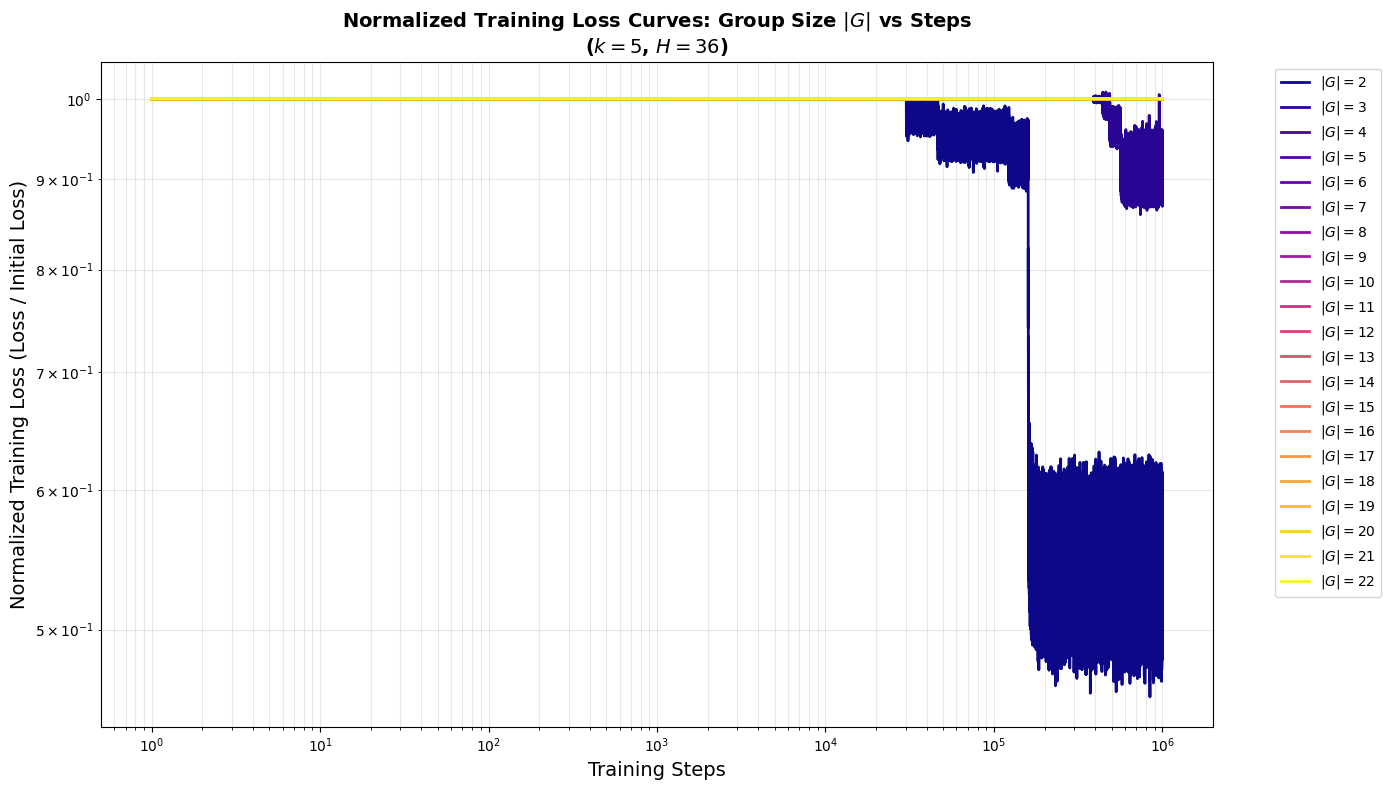

In [5]:
# Plot training loss curves for different group sizes
# Specify the hidden dimension to use
hidden_dim = 36  # Change this to plot different hidden dimensions

# Use all available p values (or filter as needed)
p_values_to_plot = [p for p in p_values if p <= 100]

for k in k_values:
    if lightweight:
        key = f"curves_k{k}_h{hidden_dim}"
        if key not in _lw:
            print(f"No curve data for k={k}, H={hidden_dim} in lightweight file")
            continue
        mat = _lw[key]  # (num_p, downsample)
        available_ps = [
            (j, p)
            for j, p in enumerate(p_values)
            if p in p_values_to_plot and not np.all(np.isnan(mat[j]))
        ]
        if not available_ps:
            print(f"No data found for k={k}, H={hidden_dim}")
            continue
        colors = plt.cm.plasma(np.linspace(0, 1, len(available_ps)))
        plt.figure(figsize=(14, 8))
        for ci, (j, p) in enumerate(available_ps):
            curve = mat[j]
            if curve[0] > 0:
                curve = curve / curve[0]
            steps = np.linspace(1, len(curve), len(curve))
            plt.loglog(steps, curve, color=colors[ci], linewidth=2, label=f"$|G|={p}$")
    else:
        curves = load_training_loss_curves(sweep_dir, k, hidden_dim, p_values_to_plot)
        if not curves:
            print(f"No data found for k={k}, H={hidden_dim}")
            continue
        colors = plt.cm.plasma(np.linspace(0, 1, len(curves)))
        plt.figure(figsize=(14, 8))
        for i, (p, loss_histories) in enumerate(sorted(curves.items())):
            normalized_histories = []
            for hist in loss_histories:
                if len(hist) > 0 and hist[0] > 0:
                    normalized_histories.append(hist / hist[0])

            if not normalized_histories:
                continue

            max_len = max(len(h) for h in normalized_histories)
            aligned = np.full((len(normalized_histories), max_len), np.nan)
            for si, h in enumerate(normalized_histories):
                aligned[si, : len(h)] = h

            mean_loss = np.nanmean(aligned, axis=0)
            steps = np.arange(1, len(mean_loss) + 1)
            plt.loglog(
                steps, mean_loss, color=colors[i], linewidth=2, label=f"$|G|={p}$"
            )

    plt.xlabel("Training Steps", fontsize=14)
    plt.ylabel("Normalized Training Loss (Loss / Initial Loss)", fontsize=14)
    plt.title(
        f"Normalized Training Loss Curves: Group Size $|G|$ vs Steps\n($k={k}$, $H={hidden_dim}$)",
        fontsize=14,
        fontweight="bold",
    )
    plt.legend(loc="best", fontsize=10, ncol=1, bbox_to_anchor=(1.05, 1))
    plt.grid(True, alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()